# Amazon Reviews Final Project Notebook

## Phase 1: Dataset Intake + Data Contract

This notebook starts with a leakage-safe intake for the fastText-formatted Amazon Reviews files in `final/data/`:

- `train.ft.txt`
- `test.ft.txt`

Phase 1 goals:
1. Parse raw lines into a canonical schema: `label_raw`, `label`, `text`
2. Validate file-level quality checks (row count, malformed lines, empty text)
3. Summarize label balance and text-length statistics
4. Lock the split policy: keep `test.ft.txt` untouched for final evaluation

In [3]:
from pathlib import Path
from collections import Counter
import random

import pandas as pd

DATA_DIR = Path("data")  # because notebook is in final/
TRAIN_PATH = DATA_DIR / "train.ft.txt"
TEST_PATH = DATA_DIR / "test.ft.txt"

assert TRAIN_PATH.exists(), f"Missing file: {TRAIN_PATH.resolve()}"
assert TEST_PATH.exists(), f"Missing file: {TEST_PATH.resolve()}"

RANDOM_SEED = 42
random.seed(RANDOM_SEED)


In [4]:
def parse_fasttext_line(line: str):
    """Parse a fastText row into canonical fields.

    Expected format: __label__X <free text>
    Returns: (label_raw, label, text, is_malformed)
    """
    raw = line.rstrip("\n")

    if not raw.startswith("__label__"):
        return None, None, "", True

    parts = raw.split(" ", 1)
    if len(parts) == 1:
        label_raw = parts[0]
        text = ""
    else:
        label_raw, text = parts[0], parts[1]

    label_map = {"__label__1": 0, "__label__2": 1}
    label = label_map.get(label_raw)
    is_malformed = label is None

    return label_raw, label, text, is_malformed


def profile_fasttext_file(path: Path):
    label_counts_raw = Counter()
    label_counts_mapped = Counter()

    row_count = 0
    malformed_rows = 0
    empty_text_rows = 0

    valid_rows = 0
    char_len_sum = 0
    word_len_sum = 0
    char_len_freq = Counter()
    word_len_freq = Counter()

    with path.open("r", encoding="utf-8", errors="replace") as f:
        for line in f:
            row_count += 1
            label_raw, label, text, malformed = parse_fasttext_line(line)

            if malformed:
                malformed_rows += 1
                continue

            label_counts_raw[label_raw] += 1
            label_counts_mapped[label] += 1

            stripped = text.strip()
            if not stripped:
                empty_text_rows += 1

            valid_rows += 1
            char_len = len(text)
            word_len = len(stripped.split()) if stripped else 0

            char_len_sum += char_len
            word_len_sum += word_len
            char_len_freq[char_len] += 1
            word_len_freq[word_len] += 1

    def pct(count: int, total: int) -> float:
        return (100.0 * count / total) if total else 0.0

    def quantile_from_freq(freq: Counter, total: int, q: float):
        if total == 0:
            return None
        target = max(1, int(q * total))
        running = 0
        for value in sorted(freq):
            running += freq[value]
            if running >= target:
                return value
        return max(freq)

    profile = {
        "file": str(path),
        "row_count": row_count,
        "malformed_rows": malformed_rows,
        "empty_text_rows": empty_text_rows,
        "label_counts_raw": dict(label_counts_raw),
        "label_counts_mapped": dict(label_counts_mapped),
        "label_0_pct": pct(label_counts_mapped.get(0, 0), valid_rows),
        "label_1_pct": pct(label_counts_mapped.get(1, 0), valid_rows),
        "char_len_mean": (char_len_sum / valid_rows) if valid_rows else None,
        "char_len_median": quantile_from_freq(char_len_freq, valid_rows, 0.50),
        "char_len_p95": quantile_from_freq(char_len_freq, valid_rows, 0.95),
        "word_len_mean": (word_len_sum / valid_rows) if valid_rows else None,
        "word_len_median": quantile_from_freq(word_len_freq, valid_rows, 0.50),
        "word_len_p95": quantile_from_freq(word_len_freq, valid_rows, 0.95),
    }

    return profile


def sample_rows(path: Path, n: int = 5, seed: int = 42):
    rng = random.Random(seed)
    reservoir = []

    with path.open("r", encoding="utf-8", errors="replace") as f:
        for i, line in enumerate(f, start=1):
            label_raw, label, text, malformed = parse_fasttext_line(line)
            if malformed:
                continue
            row = {"label_raw": label_raw, "label": label, "text": text[:200]}

            if len(reservoir) < n:
                reservoir.append(row)
            else:
                j = rng.randint(1, i)
                if j <= n:
                    reservoir[j - 1] = row

    return pd.DataFrame(reservoir)

In [5]:
train_profile = profile_fasttext_file(TRAIN_PATH)
test_profile = profile_fasttext_file(TEST_PATH)

profile_df = pd.DataFrame([train_profile, test_profile])

display_cols = [
    "file",
    "row_count",
    "malformed_rows",
    "empty_text_rows",
    "label_counts_raw",
    "label_counts_mapped",
    "label_0_pct",
    "label_1_pct",
    "char_len_mean",
    "char_len_median",
    "char_len_p95",
    "word_len_mean",
    "word_len_median",
    "word_len_p95",
]

profile_df[display_cols]

,file,row_count,malformed_rows,empty_text_rows,label_counts_raw,label_counts_mapped,label_0_pct,label_1_pct,char_len_mean,char_len_median,char_len_p95,word_len_mean,word_len_median,word_len_p95
0,data/train.ft.txt,3600000,0,0,"{'__label__2': 1800000, '__label__1': 1800000}","{1: 1800000, 0: 1800000}",50.0,50.0,431.646315,383,895,78.482733,70,161
1,data/test.ft.txt,400000,0,0,"{'__label__2': 200000, '__label__1': 200000}","{1: 200000, 0: 200000}",50.0,50.0,431.429630,383,895,78.424145,70,161


## Phase 1 Data Contract (Locked)

Canonical parsed schema used going forward:

- `label_raw` (`str`): original fastText label (`__label__1` or `__label__2`)
- `label` (`int`): mapped class (`0` for negative, `1` for positive)
- `text` (`str`): raw review text

Quality checks required before modeling:

- malformed row count
- empty text count
- class distribution
- text-length statistics (char and word)

Split policy:

- `test.ft.txt` is **held out** for final evaluation only.
- Development/tuning splits come from `train.ft.txt` only.
- Any learned preprocessing object (vectorizer/tokenizer/scaler) must be fit on train (or train folds) only.

In [6]:
print("Train sample rows")
display(sample_rows(TRAIN_PATH, n=5, seed=RANDOM_SEED))

print("\nTest sample rows")
display(sample_rows(TEST_PATH, n=5, seed=RANDOM_SEED))

Train sample rows


,label_raw,label,text
0,__label__1,0,"Dislike!: After reading the reviews, I bought ..."
1,__label__1,0,Not Worth The Money: Can get the very same pro...
2,__label__2,1,LIFE-CHANGING PRODUCT!: I purchased this juice...
3,__label__1,0,Is it supposed to be a joke?: Fought my way th...
4,__label__2,1,Tears and amazment: I was raised in the Baptis...



Test sample rows


,label_raw,label,text
0,__label__1,0,Meh: I know this is an indie film and I usuall...
1,__label__1,0,Spacesaver: These are truly a space saver. How...
2,__label__2,1,Fabulous for dry hair straightening: I can't s...
3,__label__2,1,A different approach: I think this step was a ...
4,__label__1,0,"Here today, gone tomorrow: Horrible product, j..."


## Phase 2: Narrative A (DGP) + EDA with Decision Links

### 2A. DGP Narrative (Predictive Framing)

We model Amazon review sentiment as a **predictive** problem: given review text, predict whether sentiment is negative (`0`) or positive (`1`).

**Plausible data-generating process (DGP):**
1. A user purchases a product and forms an experience.
2. Latent factors (true product quality, prior expectations, user strictness, shipping experience, category norms) affect sentiment.
3. The user chooses whether to leave a review (selection process).
4. Sentiment is expressed in text and converted into a star/label outcome.

**Observed variables:** review text and label.  
**Latent variables:** reviewer personality, product baseline quality, context (price, seasonality, urgency), and platform behavior.

**Biases to acknowledge:**
- **Selection bias:** only some buyers leave reviews.
- **Category-mix bias:** language differs by product category.
- **Expression bias:** some reviewers write long emotional text; others are brief.
- **Potential domain shift:** language patterns may evolve over time.

**Modeling implication:**
- We do **not** claim causal effects from words to product quality.
- We evaluate generalization under consistent splits and leakage-safe preprocessing.

### EDA Sampling Caveat

EDA visuals are generated on a reservoir sample (`EDA_SAMPLE_SIZE`) from training data for runtime efficiency.

Why sampling is used in this dataset size:
- Full-train EDA on 3.6M text rows is expensive in memory and runtime.
- A large random sample still preserves stable macro-patterns (class balance, length distributions, broad lexical signals).
- Faster iteration improves analysis quality by allowing repeated hypothesis checks.

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [8]:
def build_eda_sample(path: Path, n: int = 200_000, seed: int = 42):
    """Reservoir sample rows from the training file for fast EDA."""
    rng = random.Random(seed)
    reservoir = []

    with path.open("r", encoding="utf-8", errors="replace") as f:
        for i, line in enumerate(f, start=1):
            label_raw, label, text, malformed = parse_fasttext_line(line)
            if malformed:
                continue

            row = {
                "label_raw": label_raw,
                "label": label,
                "text": text,
            }

            if len(reservoir) < n:
                reservoir.append(row)
            else:
                j = rng.randint(1, i)
                if j <= n:
                    reservoir[j - 1] = row

    eda_df = pd.DataFrame(reservoir)
    eda_df["char_len"] = eda_df["text"].str.len()
    eda_df["word_len"] = eda_df["text"].str.split().str.len()
    eda_df["label_name"] = eda_df["label"].map({0: "negative", 1: "positive"})

    return eda_df


EDA_SAMPLE_SIZE = 200_000
eda_df = build_eda_sample(TRAIN_PATH, n=EDA_SAMPLE_SIZE, seed=RANDOM_SEED)
eda_df.shape

(200000, 6)

In [9]:
eda_summary = {
    "sample_rows": len(eda_df),
    "label_distribution": eda_df["label_name"].value_counts(normalize=True).round(4).to_dict(),
    "char_len_median": int(eda_df["char_len"].median()),
    "char_len_p95": int(eda_df["char_len"].quantile(0.95)),
    "word_len_median": int(eda_df["word_len"].median()),
    "word_len_p95": int(eda_df["word_len"].quantile(0.95)),
}

eda_summary

{'sample_rows': 200000,
 'label_distribution': {'positive': 0.5014, 'negative': 0.4986},
 'char_len_median': 382,
 'char_len_p95': 894,
 'word_len_median': 70,
 'word_len_p95': 161}

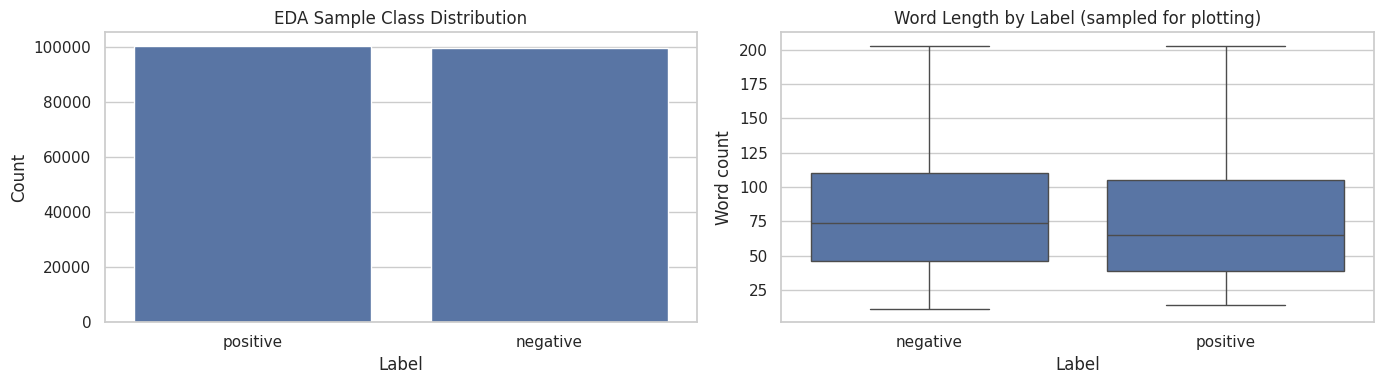

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Class balance
label_counts = eda_df["label_name"].value_counts().reset_index()
label_counts.columns = ["label_name", "count"]
sns.barplot(data=label_counts, x="label_name", y="count", ax=axes[0])
axes[0].set_title("EDA Sample Class Distribution")
axes[0].set_xlabel("Label")
axes[0].set_ylabel("Count")

# Text length by label
sns.boxplot(
    data=eda_df.sample(min(20_000, len(eda_df)), random_state=RANDOM_SEED),
    x="label_name",
    y="word_len",
    showfliers=False,
    ax=axes[1],
)
axes[1].set_title("Word Length by Label (sampled for plotting)")
axes[1].set_xlabel("Label")
axes[1].set_ylabel("Word count")

plt.tight_layout()
plt.show()

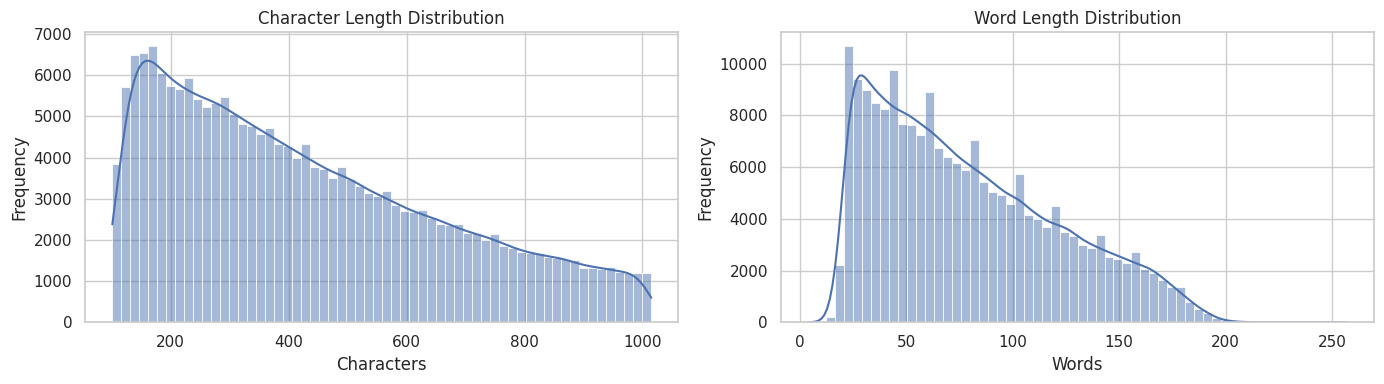

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(eda_df["char_len"], bins=60, kde=True, ax=axes[0])
axes[0].set_title("Character Length Distribution")
axes[0].set_xlabel("Characters")

sns.histplot(eda_df["word_len"], bins=60, kde=True, ax=axes[1])
axes[1].set_title("Word Length Distribution")
axes[1].set_xlabel("Words")

for ax in axes:
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [12]:
# Shortest / longest examples help identify potential noise or truncation issues
short_examples = eda_df.nsmallest(3, "word_len")[["label_name", "word_len", "text"]]
long_examples = eda_df.nlargest(3, "word_len")[["label_name", "word_len", "text"]]

print("Shortest examples")
display(short_examples)

print("Longest examples")
display(long_examples)

Shortest examples


,label_name,word_len,text
136187,positive,4,"Crash, Crash, Bang!!!!!!!!!!!!!!!!!!!!!!!!!: W..."
165206,negative,9,...[Teeth Chattering]...: ...I...am...so...sca...
180591,positive,11,it was so good I could not put it down: )()()(...


Longest examples


,label_name,word_len,text
134314,negative,257,iLok is rubbish!!: I have never been able to g...
86073,positive,216,Wonderful for diabetics: I bought this 1 year ...
125919,negative,213,"Fun, at first: I got this toy from my grandma,..."


In [13]:
from sklearn.feature_extraction.text import CountVectorizer

# Top terms per class (train-sample only) for interpretable lexical signal checks
MAX_DOCS_FOR_TERMS = 80_000
term_df = eda_df.sample(min(MAX_DOCS_FOR_TERMS, len(eda_df)), random_state=RANDOM_SEED)

vectorizer = CountVectorizer(stop_words="english", max_features=5000, ngram_range=(1, 1))
X_counts = vectorizer.fit_transform(term_df["text"])
terms = pd.Index(vectorizer.get_feature_names_out())

term_tables = {}
for class_id, class_name in [(0, "negative"), (1, "positive")]:
    mask = term_df["label"] == class_id
    class_sum = X_counts[mask.values].sum(axis=0).A1
    top_idx = class_sum.argsort()[::-1][:20]
    term_tables[class_name] = pd.DataFrame(
        {"term": terms[top_idx], "count": class_sum[top_idx]}
    )

print("Top terms in negative reviews")
display(term_tables["negative"])
print("Top terms in positive reviews")
display(term_tables["positive"])

Top terms in negative reviews


,term,count
0,book,20888
1,like,12106
2,just,12104
3,good,9755
4,don,8669
5,time,8052
6,movie,7302
7,read,6423
8,buy,6293
9,really,6292


Top terms in positive reviews


,term,count
0,book,22839
1,great,18492
2,good,13534
3,like,11109
4,read,9089
5,just,8946
6,love,8060
7,best,7324
8,time,7030
9,really,6452


### Phase 2 Decision Links (write after running cells)

Use this section to turn EDA into explicit choices:

1. **Class balance decision**  
   Since classes are close to balanced, keep standard metrics (accuracy, F1, ROC-AUC, PR-AUC) and still report all for robustness.

2. **Sequence length decision**  
   Use empirical length stats (median/p95) to choose truncation for neural/Transformer models (start around 256 or 512 tokens, then validate).

3. **Noise/outlier handling**  
   If very short or extreme-length texts degrade performance, add sensitivity checks with minimum-length filter or length clipping.

4. **Lexical signal decision**  
   If top terms clearly separate classes, prioritize a TF-IDF + linear baseline early as a strong interpretable benchmark.

5. **Leakage reminder**  
   Keep all vocabulary fitting (CountVectorizer/TF-IDF/tokenizers) on training splits only in later phases.

### DGP Assumption Clarification

We assume review text contains enough signal for useful sentiment prediction, **but unobserved factors still exist** (reviewer strictness, product baseline quality, and context). These latent factors may limit generalization under distribution shift.

This project is therefore **predictive**, not causal: performance is interpreted as out-of-sample prediction quality under the observed data support.

### DGP to EDA Checks (Template)

| DGP claim | EDA check | Evidence from current run | Modeling implication |
|---|---|---|---|
| Class process is not strongly imbalanced | Label distribution | ~50/50 in train and test | Accuracy is informative; still report F1/ROC-AUC/PR-AUC |
| Review verbosity can influence sentiment expression | Length distributions by class | Compare word-length boxplots and tails | Include length-aware sensitivity checks and truncation policy |
| Lexical sentiment cues exist | Top terms by class | Positive and negative term tables | Prioritize TF-IDF + linear baseline |
| Extreme reviews may behave differently | Outlier examples (short/long) | Inspect shortest/longest samples | Consider minimum-length / clipping sensitivity analysis |

After each EDA figure, add 1-2 bullets answering: **What decision changes because of this?**

## Phase 3: Baseline + Classical Models

### Locked evaluation protocol for Phase 3

- Use `train.ft.txt` only for development split and tuning.
- Keep `test.ft.txt` untouched for final report numbers.
- Primary metric: **F1**.
- Tie-break metric: **ROC-AUC**.
- Supporting metrics: accuracy, precision, recall, PR-AUC.

### Runtime strategy

1. **Pass 1 (fast iteration):** run on controlled subset to validate preprocessing/model wiring.
2. **Pass 2 (scaled run):** train with larger/full training data for stable final comparisons.

### Planned outputs

- `baseline_results_df`: one table with identical metrics for linear baseline and classical model.
- confusion matrix and PR curve for the strongest non-neural baseline.

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    precision_recall_curve,
)

import numpy as np

In [15]:
def load_fasttext_as_dataframe(path: Path, max_rows: int | None = None):
    rows = []
    with path.open("r", encoding="utf-8", errors="replace") as f:
        for i, line in enumerate(f, start=1):
            label_raw, label, text, malformed = parse_fasttext_line(line)
            if malformed:
                continue
            rows.append({"label": label, "text": text})
            if max_rows is not None and i >= max_rows:
                break
    return pd.DataFrame(rows)


def evaluate_binary_classifier(model, X_val, y_val):
    y_pred = model.predict(X_val)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_val)[:, 1]
    elif hasattr(model, "decision_function"):
        raw = model.decision_function(X_val)
        # Map decision scores to [0,1] for PR-AUC and ROC-AUC compatibility.
        y_score = 1 / (1 + np.exp(-raw))
    else:
        y_score = y_pred

    metrics = {
        "accuracy": accuracy_score(y_val, y_pred),
        "precision": precision_score(y_val, y_pred, zero_division=0),
        "recall": recall_score(y_val, y_pred, zero_division=0),
        "f1": f1_score(y_val, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_val, y_score),
        "pr_auc": average_precision_score(y_val, y_score),
    }

    return metrics, y_pred, y_score

In [16]:
# Pass-1 fast iteration settings (increase for pass-2 scaled run)
PHASE3_MAX_ROWS = 500_000  # None for full train file
VAL_SIZE = 0.2

phase3_df = load_fasttext_as_dataframe(TRAIN_PATH, max_rows=PHASE3_MAX_ROWS)

X_train, X_val, y_train, y_val = train_test_split(
    phase3_df["text"],
    phase3_df["label"],
    test_size=VAL_SIZE,
    random_state=RANDOM_SEED,
    stratify=phase3_df["label"],
)

print(f"Phase 3 dataset rows: {len(phase3_df):,}")
print(f"Train rows: {len(X_train):,} | Val rows: {len(X_val):,}")
print("Train class balance:")
print(y_train.value_counts(normalize=True).rename("ratio"))

Phase 3 dataset rows: 500,000
Train rows: 400,000 | Val rows: 100,000
Train class balance:
label
1    0.505565
0    0.494435
Name: ratio, dtype: float64


In [17]:
baseline_pipe = Pipeline(
    steps=[
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=True,
                strip_accents="unicode",
                stop_words="english",
                ngram_range=(1, 2),
                min_df=5,
                max_df=0.95,
                sublinear_tf=True,
                max_features=300_000,
            ),
        ),
        (
            "clf",
            LogisticRegression(
                solver="saga",
                max_iter=300,
                random_state=RANDOM_SEED,
            ),
        ),
    ]
)

baseline_pipe.fit(X_train, y_train)
baseline_metrics, baseline_pred, baseline_score = evaluate_binary_classifier(
    baseline_pipe, X_val, y_val
)
baseline_metrics

{'accuracy': 0.90517,
 'precision': 0.9004699596341725,
 'recall': 0.9133831790489754,
 'f1': 0.9068806033170655,
 'roc_auc': 0.9662499050522594,
 'pr_auc': 0.9649193324311431}

In [18]:
classical_pipe = Pipeline(
    steps=[
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=True,
                strip_accents="unicode",
                stop_words="english",
                ngram_range=(1, 2),
                min_df=5,
                max_df=0.95,
                sublinear_tf=True,
                max_features=300_000,
            ),
        ),
        (
            "clf",
            SGDClassifier(
                loss="hinge",  # linear SVM objective
                alpha=1e-5,
                max_iter=25,
                tol=1e-3,
                random_state=RANDOM_SEED,
            ),
        ),
    ]
)

classical_pipe.fit(X_train, y_train)
classical_metrics, classical_pred, classical_score = evaluate_binary_classifier(
    classical_pipe, X_val, y_val
)
classical_metrics

{'accuracy': 0.90521,
 'precision': 0.9001344269321436,
 'recall': 0.9138974602421077,
 'f1': 0.9069637336212396,
 'roc_auc': 0.9659162537948132,
 'pr_auc': 0.9645596621064674}

In [19]:
baseline_results_df = pd.DataFrame(
    [
        {"model": "TF-IDF + LogisticRegression", **baseline_metrics},
        {"model": "TF-IDF + SGDClassifier(hinge)", **classical_metrics},
    ]
)

metric_cols = ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]
baseline_results_df[metric_cols] = baseline_results_df[metric_cols].round(4)

# Sort by locked protocol: primary metric F1, tie-break ROC-AUC
baseline_results_df = baseline_results_df.sort_values(
    by=["f1", "roc_auc"], ascending=False
).reset_index(drop=True)

baseline_results_df

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,TF-IDF + SGDClassifier(hinge),0.9052,0.9001,0.9139,0.9070,0.9659,0.9646
1,TF-IDF + LogisticRegression,0.9052,0.9005,0.9134,0.9069,0.9662,0.9649


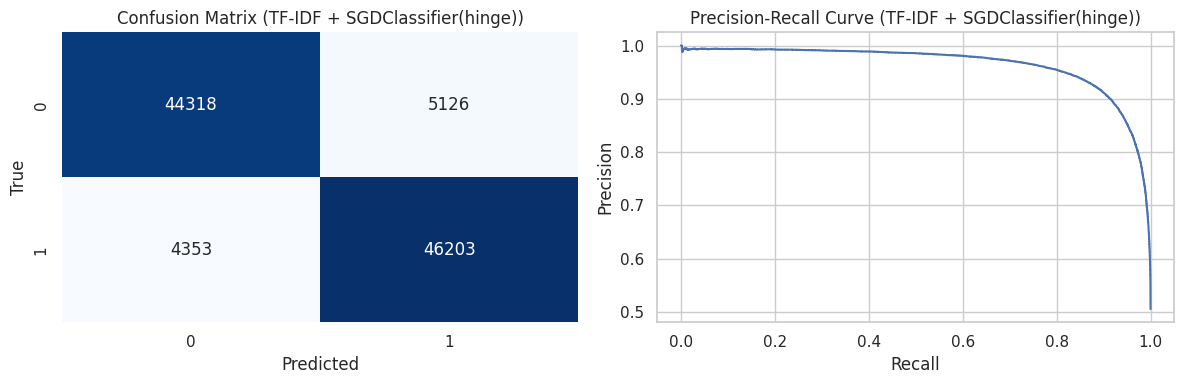

In [20]:
# Diagnostics for strongest non-neural model on validation set
best_model_name = baseline_results_df.loc[0, "model"]
if best_model_name == "TF-IDF + LogisticRegression":
    best_pred, best_score = baseline_pred, baseline_score
else:
    best_pred, best_score = classical_pred, classical_score

cm = confusion_matrix(y_val, best_pred)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    ax=ax[0],
)
ax[0].set_title(f"Confusion Matrix ({best_model_name})")
ax[0].set_xlabel("Predicted")
ax[0].set_ylabel("True")

precision, recall, _ = precision_recall_curve(y_val, best_score)
ax[1].plot(recall, precision)
ax[1].set_title(f"Precision-Recall Curve ({best_model_name})")
ax[1].set_xlabel("Recall")
ax[1].set_ylabel("Precision")
ax[1].grid(True)

plt.tight_layout()
plt.show()

### Phase 3 notes to complete after execution

- Record runtime and memory behavior for pass-1 settings.
- If metrics are stable, increase `PHASE3_MAX_ROWS` (or set to `None`) for pass-2 scaled run.
- Keep hyperparameter changes minimal and documented to preserve comparability.
- Do not touch `test.ft.txt` until final model selection is locked.

## Phase 4: Unsupervised Representation (Both Paths)

This section runs two unsupervised pipelines on train-only sampled text:

1. **TF-IDF -> TruncatedSVD -> KMeans**
2. **Sentence embeddings -> KMeans**

We evaluate stability over `k = 4..8` and interpret discovered segments.

In [21]:
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

UNSUP_SAMPLE_SIZE = 120_000
K_VALUES = [4, 5, 6, 7, 8]
UNSUP_RANDOM_STATE = RANDOM_SEED
UNSUP_SVD_COMPONENTS = 200
UNSUP_MAX_FEATURES = 120_000
UNSUP_TOP_TERMS = 12

print("Phase 4 configuration")
print({
    "UNSUP_SAMPLE_SIZE": UNSUP_SAMPLE_SIZE,
    "K_VALUES": K_VALUES,
    "UNSUP_SVD_COMPONENTS": UNSUP_SVD_COMPONENTS,
    "UNSUP_MAX_FEATURES": UNSUP_MAX_FEATURES,
    "UNSUP_RANDOM_STATE": UNSUP_RANDOM_STATE,
})

Phase 4 configuration
{'UNSUP_SAMPLE_SIZE': 120000, 'K_VALUES': [4, 5, 6, 7, 8], 'UNSUP_SVD_COMPONENTS': 200, 'UNSUP_MAX_FEATURES': 120000, 'UNSUP_RANDOM_STATE': 42}


In [22]:
def build_unsup_sample(path: Path, n: int, seed: int = 42):
    rng = random.Random(seed)
    reservoir = []

    with path.open("r", encoding="utf-8", errors="replace") as f:
        for i, line in enumerate(f, start=1):
            label_raw, label, text, malformed = parse_fasttext_line(line)
            if malformed:
                continue

            row = {
                "label": label,
                "label_name": "positive" if label == 1 else "negative",
                "text": text,
            }

            if len(reservoir) < n:
                reservoir.append(row)
            else:
                j = rng.randint(1, i)
                if j <= n:
                    reservoir[j - 1] = row

    df = pd.DataFrame(reservoir)
    df["char_len"] = df["text"].str.len()
    df["word_len"] = df["text"].str.split().str.len()
    df["text_clean"] = df["text"].str.replace(r"\s+", " ", regex=True).str.strip()
    return df


unsup_df = build_unsup_sample(TRAIN_PATH, n=UNSUP_SAMPLE_SIZE, seed=UNSUP_RANDOM_STATE)
unsup_df.shape

(120000, 6)

In [23]:
tfidf_unsup_vectorizer = TfidfVectorizer(
    lowercase=True,
    strip_accents="unicode",
    stop_words="english",
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.95,
    sublinear_tf=True,
    max_features=UNSUP_MAX_FEATURES,
)

X_unsup_tfidf = tfidf_unsup_vectorizer.fit_transform(unsup_df["text_clean"])

svd_components = min(UNSUP_SVD_COMPONENTS, max(2, X_unsup_tfidf.shape[1] - 1))
svd = TruncatedSVD(n_components=svd_components, random_state=UNSUP_RANDOM_STATE)
X_unsup_svd = svd.fit_transform(X_unsup_tfidf)

print("TF-IDF shape:", X_unsup_tfidf.shape)
print("SVD shape:", X_unsup_svd.shape)
print("Explained variance (sum):", round(float(svd.explained_variance_ratio_.sum()), 4))

TF-IDF shape: (120000, 120000)
SVD shape: (120000, 200)
Explained variance (sum): 0.0924


In [24]:
tfidf_runs = []
tfidf_labels_by_k = {}

for k in K_VALUES:
    km = KMeans(n_clusters=k, n_init=10, random_state=UNSUP_RANDOM_STATE)
    labels = km.fit_predict(X_unsup_svd)

    sil = silhouette_score(X_unsup_svd, labels, sample_size=min(20000, len(labels)), random_state=UNSUP_RANDOM_STATE)

    tfidf_runs.append(
        {
            "k": k,
            "inertia": float(km.inertia_),
            "silhouette": float(sil),
        }
    )
    tfidf_labels_by_k[k] = labels


tfidf_cluster_metrics_df = pd.DataFrame(tfidf_runs).sort_values("k").reset_index(drop=True)
tfidf_cluster_metrics_df

,k,inertia,silhouette
0,4,10453.403309,0.021337
1,5,10352.340100,0.022642
2,6,10262.138898,0.025622
3,7,10205.289478,0.005234
4,8,10097.694045,0.013471


In [25]:
best_tfidf_row = tfidf_cluster_metrics_df.sort_values(["silhouette", "k"], ascending=[False, True]).iloc[0]
best_k_tfidf = int(best_tfidf_row["k"])

unsup_tfidf_df = unsup_df.copy()
unsup_tfidf_df["cluster_tfidf"] = tfidf_labels_by_k[best_k_tfidf]

print(f"Selected TF-IDF pipeline k: {best_k_tfidf}")
print("Tie handling: highest silhouette; if tied, lower k selected.")

Selected TF-IDF pipeline k: 6
Tie handling: highest silhouette; if tied, lower k selected.


In [26]:
# Optional one-time install in notebook kernel (uncomment and run if imports fail)
%pip install -U sentence-transformers transformers ipywidgets jupyterlab_widgets widgetsnbextension


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [28]:
# Optional HF token loading from .env for authenticated Hugging Face downloads
# Expected .env entry: HF_TOKEN=hf_xxx...
from pathlib import Path
import os

try:
    from dotenv import load_dotenv
except ImportError:
    %pip install python-dotenv
    from dotenv import load_dotenv

env_candidates = [Path(".env"), Path("final/.env")]
loaded_env = None
for candidate in env_candidates:
    if candidate.exists():
        load_dotenv(candidate)
        loaded_env = candidate
        break

hf_token = os.getenv("HF_TOKEN")
if hf_token:
    os.environ["HF_TOKEN"] = hf_token

print("Loaded .env from:", str(loaded_env) if loaded_env else "not found")
print("HF token loaded:", bool(os.getenv("HF_TOKEN")))

Loaded .env from: .env
HF token loaded: True


In [29]:
try:
    from sentence_transformers import SentenceTransformer
except ImportError as e:
    raise ImportError(
        "sentence-transformers is required for Phase 4 embedding pipeline. "
        "Install with: pip install sentence-transformers"
    ) from e

EMB_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
EMB_BATCH_SIZE = 256

emb_model = SentenceTransformer(EMB_MODEL_NAME)
X_unsup_emb = emb_model.encode(
    unsup_df["text_clean"].tolist(),
    batch_size=EMB_BATCH_SIZE,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True,
)

print("Embedding shape:", X_unsup_emb.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/469 [00:00<?, ?it/s]

Embedding shape: (120000, 384)


In [30]:
emb_runs = []
emb_labels_by_k = {}

for k in K_VALUES:
    km = KMeans(n_clusters=k, n_init=10, random_state=UNSUP_RANDOM_STATE)
    labels = km.fit_predict(X_unsup_emb)

    sil = silhouette_score(X_unsup_emb, labels, sample_size=min(20000, len(labels)), random_state=UNSUP_RANDOM_STATE)

    emb_runs.append(
        {
            "k": k,
            "inertia": float(km.inertia_),
            "silhouette": float(sil),
        }
    )
    emb_labels_by_k[k] = labels


emb_cluster_metrics_df = pd.DataFrame(emb_runs).sort_values("k").reset_index(drop=True)
emb_cluster_metrics_df

,k,inertia,silhouette
0,4,96326.406250,0.040311
1,5,95157.460938,0.043395
2,6,94366.312500,0.033464
3,7,93591.125000,0.034703
4,8,92927.460938,0.036571


In [31]:
best_emb_row = emb_cluster_metrics_df.sort_values(["silhouette", "k"], ascending=[False, True]).iloc[0]
best_k_emb = int(best_emb_row["k"])

unsup_emb_df = unsup_df.copy()
unsup_emb_df["cluster_emb"] = emb_labels_by_k[best_k_emb]

print(f"Selected embedding pipeline k: {best_k_emb}")
print("Tie handling: highest silhouette; if tied, lower k selected.")

Selected embedding pipeline k: 5
Tie handling: highest silhouette; if tied, lower k selected.


In [32]:
def build_cluster_profile(df: pd.DataFrame, cluster_col: str):
    size_df = (
        df.groupby(cluster_col)
        .size()
        .rename("n_samples")
        .reset_index()
        .sort_values("n_samples", ascending=False)
    )

    class_mix = (
        pd.crosstab(df[cluster_col], df["label_name"], normalize="index")
        .reset_index()
    )

    length_stats = (
        df.groupby(cluster_col)[["word_len", "char_len"]]
        .mean()
        .round(2)
        .reset_index()
    )

    profile = size_df.merge(class_mix, on=cluster_col, how="left").merge(length_stats, on=cluster_col, how="left")
    return profile


def representative_examples(df: pd.DataFrame, cluster_col: str, n: int = 3, seed: int = 42):
    sampled_parts = []

    for cluster_id, group in df.groupby(cluster_col):
        part = group.sample(min(n, len(group)), random_state=seed).copy()
        # Reattach cluster id explicitly to avoid pandas groupby-apply behavior differences.
        part[cluster_col] = cluster_id
        sampled_parts.append(part[[cluster_col, "label_name", "word_len", "text"]])

    return pd.concat(sampled_parts, ignore_index=True)

In [37]:
tfidf_cluster_profile_df = build_cluster_profile(unsup_tfidf_df, "cluster_tfidf")
emb_cluster_profile_df = build_cluster_profile(unsup_emb_df, "cluster_emb")

print("TF-IDF cluster profile")
display(tfidf_cluster_profile_df)

print("Embedding cluster profile")
display(emb_cluster_profile_df)

TF-IDF cluster profile


,cluster_tfidf,n_samples,negative,positive,word_len,char_len
0,2,54049,0.510962,0.489038,72.87,397.70
1,5,30169,0.446617,0.553383,86.32,482.81
2,0,13611,0.360517,0.639483,85.63,469.69
3,4,9736,0.616783,0.383217,75.96,413.79
4,1,8783,0.526927,0.473073,82.02,449.94
5,3,3652,0.984118,0.015882,72.26,391.06


Embedding cluster profile


,cluster_emb,n_samples,negative,positive,word_len,char_len
0,1,34036,0.455518,0.544482,84.19,472.06
1,3,31870,0.497960,0.502040,71.69,385.97
2,0,18825,0.508898,0.491102,78.02,430.63
3,2,18087,0.704926,0.295074,77.28,419.41
4,4,17182,0.379525,0.620475,82.39,454.11


In [33]:
terms = np.array(tfidf_unsup_vectorizer.get_feature_names_out())

# Map SVD-space cluster centers back to TF-IDF term space for interpretability.
km_best_tfidf = KMeans(n_clusters=best_k_tfidf, n_init=10, random_state=UNSUP_RANDOM_STATE)
_ = km_best_tfidf.fit(X_unsup_svd)

centers_tfidf_space = km_best_tfidf.cluster_centers_.dot(svd.components_)

top_terms_rows = []
for cluster_id in range(best_k_tfidf):
    top_idx = centers_tfidf_space[cluster_id].argsort()[::-1][:UNSUP_TOP_TERMS]
    top_terms = ", ".join(terms[top_idx])
    top_terms_rows.append({"cluster_tfidf": cluster_id, "top_terms": top_terms})

tfidf_top_terms_df = pd.DataFrame(top_terms_rows)
tfidf_top_terms_df

,cluster_tfidf,top_terms
0,0,"cd, album, music, songs, song, like, great, be..."
1,1,"movie, film, movies, watch, good, great, like,..."
2,2,"great, good, just, like, use, time, bought, bu..."
3,3,"waste, money, waste money, don waste, don, was..."
4,4,"product, great, great product, use, good, buy,..."
5,5,"book, read, books, reading, story, good, autho..."


In [34]:
print("has representative_examples:", "representative_examples" in globals())
print("has unsup_tfidf_df:", "unsup_tfidf_df" in globals())
print("has unsup_emb_df:", "unsup_emb_df" in globals())

if "unsup_tfidf_df" in globals():
    print("tfidf columns contain cluster_tfidf:", "cluster_tfidf" in unsup_tfidf_df.columns)
if "unsup_emb_df" in globals():
    print("emb columns contain cluster_emb:", "cluster_emb" in unsup_emb_df.columns)

has representative_examples: True
has unsup_tfidf_df: True
has unsup_emb_df: True
tfidf columns contain cluster_tfidf: True
emb columns contain cluster_emb: True


In [35]:
def representative_examples(df, cluster_col: str, n: int = 3, seed: int = 42):
    sampled_parts = []
    for cluster_id, group in df.groupby(cluster_col):
        part = group.sample(min(n, len(group)), random_state=seed).copy()
        part[cluster_col] = cluster_id  # force column presence
        sampled_parts.append(part[[cluster_col, "label_name", "word_len", "text"]])
    return pd.concat(sampled_parts, ignore_index=True)
    
def _show_cluster_examples(df, cluster_col, title, n=3):
    required_cols = {cluster_col, "label_name", "word_len", "text"}
    if df is None or not required_cols.issubset(df.columns):
        print(f"{title} skipped: missing required columns for {cluster_col}.")
        return None

    out = representative_examples(df, cluster_col, n=n, seed=RANDOM_SEED).sort_values(
        [cluster_col, "word_len"], ascending=[True, False]
    )
    print(title)
    display(out)
    return out


tfidf_examples_df = _show_cluster_examples(
    unsup_tfidf_df,
    "cluster_tfidf",
    "Representative TF-IDF cluster examples",
    n=3,
)

emb_examples_df = _show_cluster_examples(
    unsup_emb_df,
    "cluster_emb",
    "Representative embedding cluster examples",
    n=3,
)

Representative TF-IDF cluster examples


,cluster_tfidf,label_name,word_len,text
2,0,positive,85,A High Bar set for Worship music: The First Ci...
0,0,positive,75,Still a good Buy: When i firsted listened to i...
1,0,negative,44,"Good but skimpy: For true Eva Cassidy lovers, ..."
5,1,positive,67,Good Movie: I thought this movie was going to ...
3,1,positive,66,Lovely songs: Vincent Youmans was a master tun...
4,1,negative,56,Ice Age:Dawn of the Dinosaurs: While the quali...
8,2,positive,149,Clearing up some questions/critiques: Unit app...
7,2,positive,61,Hot item: When I first received the trimmer th...
6,2,positive,49,Awesome!!!!!: I have always loved Terrance Hil...
10,3,negative,132,"Kind of pointless , find better info online an..."


Representative embedding cluster examples


,cluster_emb,label_name,word_len,text
2,0,positive,88,"Surprisingly, I loved it!: Usually, when my hu..."
1,0,positive,85,Kids are Payne's!: Damon Wayans is absolutely ...
0,0,positive,30,How Could You Not Have seen this?: A Must for ...
3,1,negative,173,"Undeveloped in several areas: Ok, right off th..."
5,1,positive,97,The Truth: A real testament to Franken's work;...
4,1,positive,20,Enjoy this series!: I love this series. The pi...
8,2,negative,122,Sub-par Product with about 60% Compression: Do...
6,2,negative,50,Doesn't work: Way too complicated. My son trie...
7,2,negative,24,JAWBONE: I bought this at theAT&T; store. The ...
11,3,positive,155,"I generally have all the flexibility of a 2x4,..."


In [38]:
tfidf_cluster_profile_with_terms_df = tfidf_cluster_profile_df.merge(
    tfidf_top_terms_df,
    on="cluster_tfidf",
    how="left",
)

tfidf_cluster_profile_with_terms_df

,cluster_tfidf,n_samples,negative,positive,word_len,char_len,top_terms
0,2,54049,0.510962,0.489038,72.87,397.70,"great, good, just, like, use, time, bought, bu..."
1,5,30169,0.446617,0.553383,86.32,482.81,"book, read, books, reading, story, good, autho..."
2,0,13611,0.360517,0.639483,85.63,469.69,"cd, album, music, songs, song, like, great, be..."
3,4,9736,0.616783,0.383217,75.96,413.79,"product, great, great product, use, good, buy,..."
4,1,8783,0.526927,0.473073,82.02,449.94,"movie, film, movies, watch, good, great, like,..."
5,3,3652,0.984118,0.015882,72.26,391.06,"waste, money, waste money, don waste, don, was..."


In [40]:
tfidf_plot_df = tfidf_cluster_metrics_df.copy()
tfidf_plot_df["pipeline"] = "tfidf_svd_kmeans"

emb_plot_df = emb_cluster_metrics_df.copy()
emb_plot_df["pipeline"] = "embedding_kmeans"

phase4_compare_df = pd.concat([tfidf_plot_df, emb_plot_df], ignore_index=True)
phase4_compare_df

,k,inertia,silhouette,pipeline
0,4,10453.403309,0.021337,tfidf_svd_kmeans
1,5,10352.340100,0.022642,tfidf_svd_kmeans
2,6,10262.138898,0.025622,tfidf_svd_kmeans
3,7,10205.289478,0.005234,tfidf_svd_kmeans
4,8,10097.694045,0.013471,tfidf_svd_kmeans
5,4,96326.406250,0.040311,embedding_kmeans
6,5,95157.460938,0.043395,embedding_kmeans
7,6,94366.312500,0.033464,embedding_kmeans
8,7,93591.125000,0.034703,embedding_kmeans
9,8,92927.460938,0.036571,embedding_kmeans


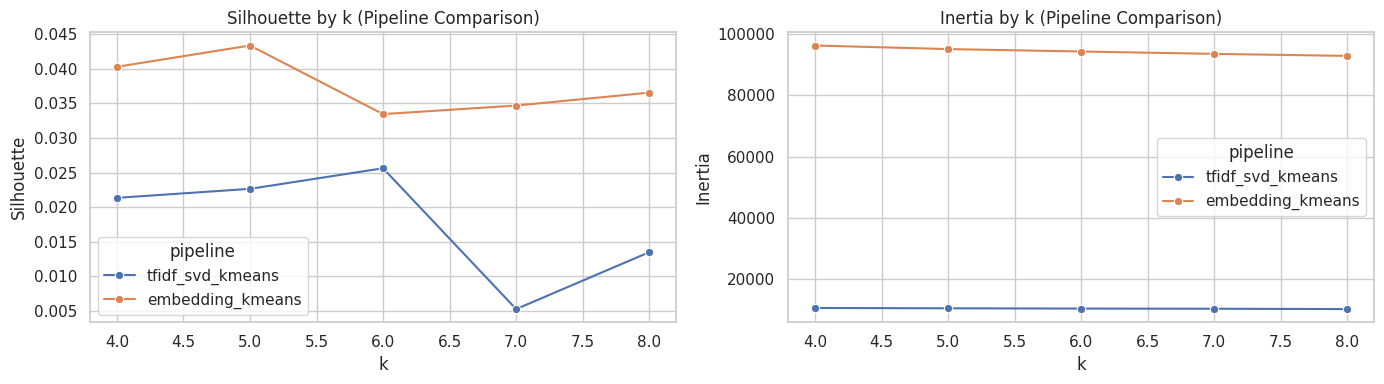

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.lineplot(data=phase4_compare_df, x="k", y="silhouette", hue="pipeline", marker="o", ax=axes[0])
axes[0].set_title("Silhouette by k (Pipeline Comparison)")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Silhouette")

sns.lineplot(data=phase4_compare_df, x="k", y="inertia", hue="pipeline", marker="o", ax=axes[1])
axes[1].set_title("Inertia by k (Pipeline Comparison)")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Inertia")

plt.tight_layout()
plt.show()

### Phase 4 Stability and Comparison Notes

Complete these bullets after running the tables/plots:

- **Stability over k=4..8:** report whether silhouette changes smoothly or is highly sensitive to `k`.
- **Selected k values:**
  - TF-IDF/SVD/KMeans: `best_k_tfidf`
  - Embedding/KMeans: `best_k_emb`
- **Interpretability tradeoff:**
  - TF-IDF path is usually easier to interpret using top terms.
  - Embedding path may capture broader semantic similarity.
- **Caveat:** clusters are descriptive structures in text space, not causal customer segments.

### Bridge to Supervised Modeling (Required)

Use these links in later phases:

1. If clusters show different class mixes and lexical/semantic profiles, this supports **heterogeneity** in sentiment language and motivates non-linear models.
2. Use TF-IDF baseline as the interpretability anchor; use embedding/Transformer models to capture context not visible in sparse term counts.
3. Optional experiment in Phase 5+: add cluster ID as an auxiliary feature in a classical model and compare against the no-cluster baseline.
4. If performance gain is marginal, keep unsupervised outputs primarily as explanatory evidence rather than production features.
5. Keep leakage-safe rule: clustering/vectorization remains train-only for any supervised integration.

## Phase 5: Neural Network + Transformer (Balanced)

This phase adds:
- one non-Transformer NN,
- one Transformer model (`distilbert-base-uncased`),
- shared metrics aligned with Phase 3,
- and training-dynamics evidence for model comparison.

`test.ft.txt` remains untouched in this phase.

In [42]:
import time
import random
import platform

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    precision_recall_curve,
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    get_linear_schedule_with_warmup,
)

sns.set_theme(style="whitegrid")

In [43]:
# Phase 5 configuration (balanced strategy)
TRAIN_SUBSET_ROWS = 120_000
TRAIN_SCALED_ROWS = None  # debug-safe default; enable after subset succeeds
VAL_SIZE = 0.2

# Shared model selection policy
PRIMARY_METRIC = "f1"
TIE_BREAK_METRIC = "roc_auc"

# NN settings
NN_VOCAB_SIZE = 50_000
NN_MAX_LEN = 256
NN_EMB_DIM = 128
NN_HIDDEN_DIM = 128
NN_DROPOUT = 0.2
NN_BATCH_SIZE = 256
NN_EPOCHS = 6
NN_LR = 1e-3
NN_PATIENCE = 2

# Transformer settings
TR_MODEL_NAME = "distilbert-base-uncased"
TR_MAX_LEN = 96
TR_BATCH_SIZE = 2
TR_GRAD_ACCUM_STEPS = 8
TR_EPOCHS = 1
TR_LR = 2e-5
TR_WEIGHT_DECAY = 0.01
TR_WARMUP_RATIO = 0.1
TR_MAX_STEPS_PER_EPOCH = 1200  # guardrail against very long runs

SEED = RANDOM_SEED if "RANDOM_SEED" in globals() else 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print({
    "device": str(DEVICE),
    "subset_rows": TRAIN_SUBSET_ROWS,
    "scaled_rows": TRAIN_SCALED_ROWS,
    "python": platform.python_version(),
})

{'device': 'cuda', 'subset_rows': 120000, 'scaled_rows': None, 'python': '3.12.3'}


/home/themad/Documents/yeshiva/dataScience/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:1061: UserWarning: Can't initialize NVML
  raw_cnt = _raw_device_count_nvml()


In [44]:
def load_train_dataframe(max_rows):
    if "load_fasttext_as_dataframe" in globals():
        return load_fasttext_as_dataframe(TRAIN_PATH, max_rows=max_rows)

    rows = []
    with TRAIN_PATH.open("r", encoding="utf-8", errors="replace") as f:
        for i, line in enumerate(f, start=1):
            label_raw, label, text, malformed = parse_fasttext_line(line)
            if not malformed:
                rows.append({"label": label, "text": text})
            if max_rows is not None and i >= max_rows:
                break
    return pd.DataFrame(rows)


def split_train_val(df):
    return train_test_split(
        df["text"],
        df["label"],
        test_size=VAL_SIZE,
        random_state=SEED,
        stratify=df["label"],
    )


def compute_binary_metrics(y_true, y_pred, y_score):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_score),
        "pr_auc": average_precision_score(y_true, y_score),
    }


train_subset_df = load_train_dataframe(TRAIN_SUBSET_ROWS)
X_train_text, X_val_text, y_train, y_val = split_train_val(train_subset_df)

print(f"Phase 5 subset rows: {len(train_subset_df):,}")
print(f"Train: {len(X_train_text):,} | Val: {len(X_val_text):,}")
print("Val class ratio:")
print(y_val.value_counts(normalize=True).rename("ratio"))

Phase 5 subset rows: 120,000
Train: 96,000 | Val: 24,000
Val class ratio:
label
1    0.506417
0    0.493583
Name: ratio, dtype: float64


Phase 5 split uses the same policy as Phase 3 (stratified train/validation from `train.ft.txt`, fixed seed). `test.ft.txt` remains untouched for final evaluation in Phase 6.

In [45]:
from collections import Counter


def basic_tokenize(text: str):
    return text.lower().split()


def build_vocab(texts, max_vocab=50000, min_freq=2):
    counter = Counter()
    for t in texts:
        counter.update(basic_tokenize(t))

    vocab = {"<pad>": 0, "<unk>": 1}
    for tok, freq in counter.most_common(max_vocab - 2):
        if freq < min_freq:
            continue
        vocab[tok] = len(vocab)
    return vocab


def encode_text(text, vocab, max_len):
    ids = [vocab.get(tok, vocab["<unk>"]) for tok in basic_tokenize(text)[:max_len]]
    if len(ids) < max_len:
        ids += [vocab["<pad>"]] * (max_len - len(ids))
    return ids


class TextDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len):
        self.texts = list(texts)
        self.labels = list(labels)
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        x = torch.tensor(encode_text(self.texts[idx], self.vocab, self.max_len), dtype=torch.long)
        y = torch.tensor(self.labels[idx], dtype=torch.float32)
        return x, y


class SimpleTextNN(nn.Module):
    def __init__(self, vocab_size, emb_dim=128, hidden_dim=128, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.fc1 = nn.Linear(emb_dim, hidden_dim)
        self.dropout = nn.Dropout(dropout)
        self.fc_out = nn.Linear(hidden_dim, 1)

    def forward(self, input_ids):
        emb = self.embedding(input_ids)  # [B, L, D]
        pooled = emb.mean(dim=1)         # [B, D]
        h = torch.relu(self.fc1(pooled))
        h = self.dropout(h)
        logits = self.fc_out(h).squeeze(1)
        return logits

In [46]:


def stable_sigmoid(x):
    x = np.asarray(x, dtype=np.float64)
    return np.where(
        x >= 0,
        1.0 / (1.0 + np.exp(-x)),
        np.exp(x) / (1.0 + np.exp(x)),
    )


def run_nn_experiment(df, run_name="subset"):
    X_train, X_val, y_tr, y_va = split_train_val(df)

    vocab = build_vocab(X_train, max_vocab=NN_VOCAB_SIZE)
    train_ds = TextDataset(X_train, y_tr.values, vocab, NN_MAX_LEN)
    val_ds = TextDataset(X_val, y_va.values, vocab, NN_MAX_LEN)

    train_loader = DataLoader(train_ds, batch_size=NN_BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=NN_BATCH_SIZE, shuffle=False)

    model = SimpleTextNN(
        vocab_size=len(vocab),
        emb_dim=NN_EMB_DIM,
        hidden_dim=NN_HIDDEN_DIM,
        dropout=NN_DROPOUT,
    ).to(DEVICE)

    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=NN_LR)

    history = []
    best_val_loss = float("inf")
    best_state = None
    patience_counter = 0

    t0 = time.time()

    for epoch in range(1, NN_EPOCHS + 1):
        model.train()
        train_losses = []
        for x_batch, y_batch in train_loader:
            x_batch, y_batch = x_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()
            logits = model(x_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        val_logits_all, val_labels_all = [], []
        with torch.no_grad():
            for x_batch, y_batch in val_loader:
                x_batch, y_batch = x_batch.to(DEVICE), y_batch.to(DEVICE)
                logits = model(x_batch)
                loss = criterion(logits, y_batch)
                val_losses.append(loss.item())
                val_logits_all.append(logits.cpu())
                val_labels_all.append(y_batch.cpu())

        val_logits = torch.cat(val_logits_all).numpy()
        val_true = torch.cat(val_labels_all).numpy().astype(int)
        val_prob = stable_sigmoid(val_logits)
        val_pred = (val_prob >= 0.5).astype(int)

        epoch_metrics = compute_binary_metrics(val_true, val_pred, val_prob)

        train_loss = float(np.mean(train_losses))
        val_loss = float(np.mean(val_losses))
        history.append(
            {
                "epoch": epoch,
                "train_loss": train_loss,
                "val_loss": val_loss,
                "val_f1": epoch_metrics["f1"],
                "val_roc_auc": epoch_metrics["roc_auc"],
            }
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= NN_PATIENCE:
                break

    if best_state is not None:
        model.load_state_dict(best_state)
        model.to(DEVICE)

    # Final eval with best checkpoint
    model.eval()
    val_logits_all, val_labels_all = [], []
    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch = x_batch.to(DEVICE)
            logits = model(x_batch)
            val_logits_all.append(logits.cpu())
            val_labels_all.append(y_batch)

    val_logits = torch.cat(val_logits_all).numpy()
    val_true = torch.cat(val_labels_all).numpy().astype(int)
    val_prob = stable_sigmoid(val_logits)
    val_pred = (val_prob >= 0.5).astype(int)
    metrics = compute_binary_metrics(val_true, val_pred, val_prob)

    out = {
        "run_name": run_name,
        "history_df": pd.DataFrame(history),
        "metrics": metrics,
        "y_true": val_true,
        "y_pred": val_pred,
        "y_score": val_prob,
        "runtime_sec": time.time() - t0,
        "n_train": len(X_train),
        "n_val": len(X_val),
        "vocab_size": len(vocab),
    }
    return out

In [47]:
nn_subset_result = run_nn_experiment(train_subset_df, run_name="nn_subset")

print("NN subset metrics:")
print({k: round(v, 4) for k, v in nn_subset_result["metrics"].items()})
print("NN runtime (sec):", round(nn_subset_result["runtime_sec"], 2))

nn_subset_result["history_df"]

NN subset metrics:
{'accuracy': 0.8866, 'precision': 0.8882, 'recall': 0.8878, 'f1': 0.888, 'roc_auc': 0.9534, 'pr_auc': 0.9543}
NN runtime (sec): 40.36


,epoch,train_loss,val_loss,val_f1,val_roc_auc
0,1,0.500441,0.350604,0.854429,0.925647
1,2,0.294011,0.292989,0.881857,0.947395
2,3,0.232008,0.277114,0.887993,0.953429
3,4,0.194430,0.278202,0.891279,0.955052
4,5,0.165522,0.286907,0.891125,0.955081


In [48]:
# Optional scaled run for NN
if TRAIN_SCALED_ROWS is not None:
    train_scaled_df = load_train_dataframe(TRAIN_SCALED_ROWS)
    nn_scaled_result = run_nn_experiment(train_scaled_df, run_name="nn_scaled")
    print("NN scaled metrics:")
    print({k: round(v, 4) for k, v in nn_scaled_result["metrics"].items()})
    print("NN scaled runtime (sec):", round(nn_scaled_result["runtime_sec"], 2))
else:
    nn_scaled_result = None
    print("TRAIN_SCALED_ROWS=None: skipping NN scaled run")

TRAIN_SCALED_ROWS=None: skipping NN scaled run


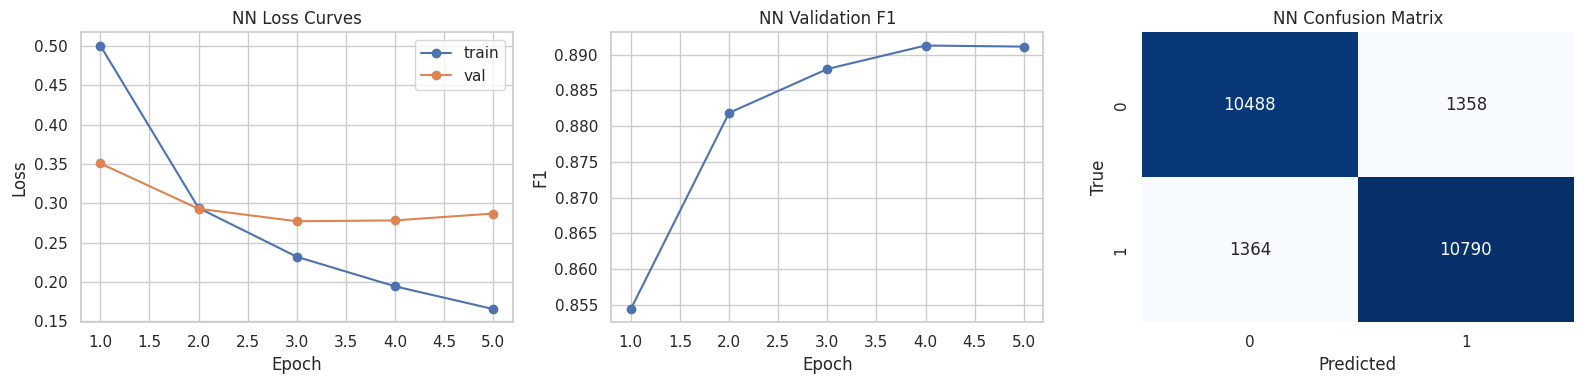

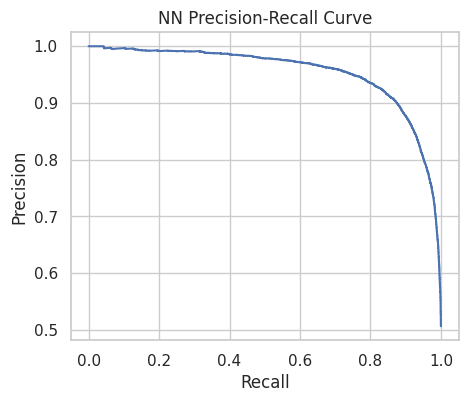

In [49]:
# NN training dynamics and diagnostics
nn_plot_result = nn_scaled_result if nn_scaled_result is not None else nn_subset_result
nn_hist = nn_plot_result["history_df"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(nn_hist["epoch"], nn_hist["train_loss"], marker="o", label="train")
axes[0].plot(nn_hist["epoch"], nn_hist["val_loss"], marker="o", label="val")
axes[0].set_title("NN Loss Curves")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(nn_hist["epoch"], nn_hist["val_f1"], marker="o")
axes[1].set_title("NN Validation F1")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("F1")

cm = confusion_matrix(nn_plot_result["y_true"], nn_plot_result["y_pred"])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[2])
axes[2].set_title("NN Confusion Matrix")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("True")

plt.tight_layout()
plt.show()

prec, rec, _ = precision_recall_curve(nn_plot_result["y_true"], nn_plot_result["y_score"])
plt.figure(figsize=(5, 4))
plt.plot(rec, prec)
plt.title("NN Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(True)
plt.show()

In [50]:
class HFTextDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = list(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item


def eval_transformer(model, data_loader):
    model.eval()
    losses = []
    y_true, y_pred, y_score = [], [], []

    with torch.no_grad():
        for batch in data_loader:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            outputs = model(**batch)
            loss = outputs.loss
            logits = outputs.logits

            losses.append(loss.item())
            probs = torch.softmax(logits, dim=1)[:, 1]
            preds = torch.argmax(logits, dim=1)

            y_true.extend(batch["labels"].cpu().numpy().tolist())
            y_pred.extend(preds.cpu().numpy().tolist())
            y_score.extend(probs.cpu().numpy().tolist())

    metrics = compute_binary_metrics(np.array(y_true), np.array(y_pred), np.array(y_score))
    return float(np.mean(losses)), metrics, np.array(y_true), np.array(y_pred), np.array(y_score)


def run_transformer_experiment(df, run_name="tr_subset"):
    X_train, X_val, y_tr, y_va = split_train_val(df)

    tokenizer = AutoTokenizer.from_pretrained(TR_MODEL_NAME)
    model = AutoModelForSequenceClassification.from_pretrained(TR_MODEL_NAME, num_labels=2)
    model.to(DEVICE)

    train_enc = tokenizer(list(X_train), truncation=True, padding=False, max_length=TR_MAX_LEN)
    val_enc = tokenizer(list(X_val), truncation=True, padding=False, max_length=TR_MAX_LEN)

    train_ds = HFTextDataset(train_enc, y_tr.values)
    val_ds = HFTextDataset(val_enc, y_va.values)

    collator = DataCollatorWithPadding(tokenizer=tokenizer)
    train_loader = DataLoader(train_ds, batch_size=TR_BATCH_SIZE, shuffle=True, collate_fn=collator)
    val_loader = DataLoader(val_ds, batch_size=TR_BATCH_SIZE, shuffle=False, collate_fn=collator)

    optimizer = torch.optim.AdamW(model.parameters(), lr=TR_LR, weight_decay=TR_WEIGHT_DECAY)
    total_steps = max(1, (len(train_loader) // TR_GRAD_ACCUM_STEPS) * TR_EPOCHS)
    warmup_steps = int(TR_WARMUP_RATIO * total_steps)
    scheduler = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)

    history = []
    best_state = None
    best_val_loss = float("inf")

    t0 = time.time()

    for epoch in range(1, TR_EPOCHS + 1):
        epoch_start = time.time()
        print(f"[{run_name}] epoch {epoch}/{TR_EPOCHS} started")
        model.train()
        optimizer.zero_grad()
        train_losses = []

        for step, batch in enumerate(train_loader, start=1):
            if step > TR_MAX_STEPS_PER_EPOCH:
                print(f"[{run_name}] reached TR_MAX_STEPS_PER_EPOCH={TR_MAX_STEPS_PER_EPOCH}; breaking early")
                break
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            outputs = model(**batch)
            loss = outputs.loss / TR_GRAD_ACCUM_STEPS
            loss.backward()
            train_losses.append(loss.item() * TR_GRAD_ACCUM_STEPS)

            if step % TR_GRAD_ACCUM_STEPS == 0:
                optimizer.step()
                scheduler.step()
                optimizer.zero_grad()

        train_loss = float(np.mean(train_losses))
        val_loss, val_metrics, _, _, _ = eval_transformer(model, val_loader)

        print(f"[{run_name}] epoch {epoch} done in {time.time() - epoch_start:.1f}s | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_f1={val_metrics['f1']:.4f}")

        history.append(
            {
                "epoch": epoch,
                "train_loss": train_loss,
                "val_loss": val_loss,
                "val_f1": val_metrics["f1"],
                "val_roc_auc": val_metrics["roc_auc"],
            }
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)
        model.to(DEVICE)

    final_val_loss, final_metrics, y_true, y_pred, y_score = eval_transformer(model, val_loader)

    # Qualitative examples: highest-confidence correct/incorrect
    val_texts = list(X_val)
    confidence = np.abs(y_score - 0.5)
    correctness = (y_pred == y_true)

    correct_idx = np.where(correctness)[0]
    wrong_idx = np.where(~correctness)[0]

    def top_examples(indices, topn=2):
        if len(indices) == 0:
            return []
        ranked = indices[np.argsort(confidence[indices])[::-1][:topn]]
        out = []
        for idx in ranked:
            out.append(
                {
                    "text": val_texts[idx][:220],
                    "true": int(y_true[idx]),
                    "pred": int(y_pred[idx]),
                    "score_pos": float(y_score[idx]),
                }
            )
        return out

    return {
        "run_name": run_name,
        "history_df": pd.DataFrame(history),
        "metrics": final_metrics,
        "val_loss": final_val_loss,
        "y_true": y_true,
        "y_pred": y_pred,
        "y_score": y_score,
        "runtime_sec": time.time() - t0,
        "n_train": len(X_train),
        "n_val": len(X_val),
        "qual_examples": {
            "correct": top_examples(correct_idx, topn=2),
            "incorrect": top_examples(wrong_idx, topn=2),
        },
    }

In [51]:
try:
    tr_subset_result = run_transformer_experiment(train_subset_df, run_name="tr_subset")
except RuntimeError as e:
    if "out of memory" in str(e).lower() and torch.cuda.is_available():
        print("CUDA OOM encountered. Retrying transformer subset run on CPU with same settings...")
        torch.cuda.empty_cache()
        DEVICE = torch.device("cpu")
        tr_subset_result = run_transformer_experiment(train_subset_df, run_name="tr_subset_cpu_fallback")
    else:
        raise

print("Transformer subset metrics:")
print({k: round(v, 4) for k, v in tr_subset_result["metrics"].items()})
print("Transformer runtime (sec):", round(tr_subset_result["runtime_sec"], 2))

tr_subset_result["history_df"]


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[tr_subset] epoch 1/1 started
[tr_subset] reached TR_MAX_STEPS_PER_EPOCH=1200; breaking early
[tr_subset] epoch 1 done in 1196.6s | train_loss=0.6442 | val_loss=0.3880 | val_f1=0.8738
Transformer subset metrics:
{'accuracy': 0.88, 'precision': 0.9351, 'recall': 0.8201, 'f1': 0.8738, 'roc_auc': 0.9526, 'pr_auc': 0.9552}
Transformer runtime (sec): 1841.09


,epoch,train_loss,val_loss,val_f1,val_roc_auc
0,1,0.644205,0.387954,0.8738,0.952566


In [52]:
# Optional scaled run for Transformer
if TRAIN_SCALED_ROWS is not None:
    train_scaled_df = load_train_dataframe(TRAIN_SCALED_ROWS)
    try:
        tr_scaled_result = run_transformer_experiment(train_scaled_df, run_name="tr_scaled")
    except RuntimeError as e:
        if "out of memory" in str(e).lower() and torch.cuda.is_available():
            print("CUDA OOM encountered. Retrying transformer scaled run on CPU...")
            torch.cuda.empty_cache()
            DEVICE = torch.device("cpu")
            tr_scaled_result = run_transformer_experiment(train_scaled_df, run_name="tr_scaled_cpu_fallback")
        else:
            raise
    print("Transformer scaled metrics:")
    print({k: round(v, 4) for k, v in tr_scaled_result["metrics"].items()})
    print("Transformer scaled runtime (sec):", round(tr_scaled_result["runtime_sec"], 2))
else:
    tr_scaled_result = None
    print("TRAIN_SCALED_ROWS=None: skipping Transformer scaled run")


TRAIN_SCALED_ROWS=None: skipping Transformer scaled run


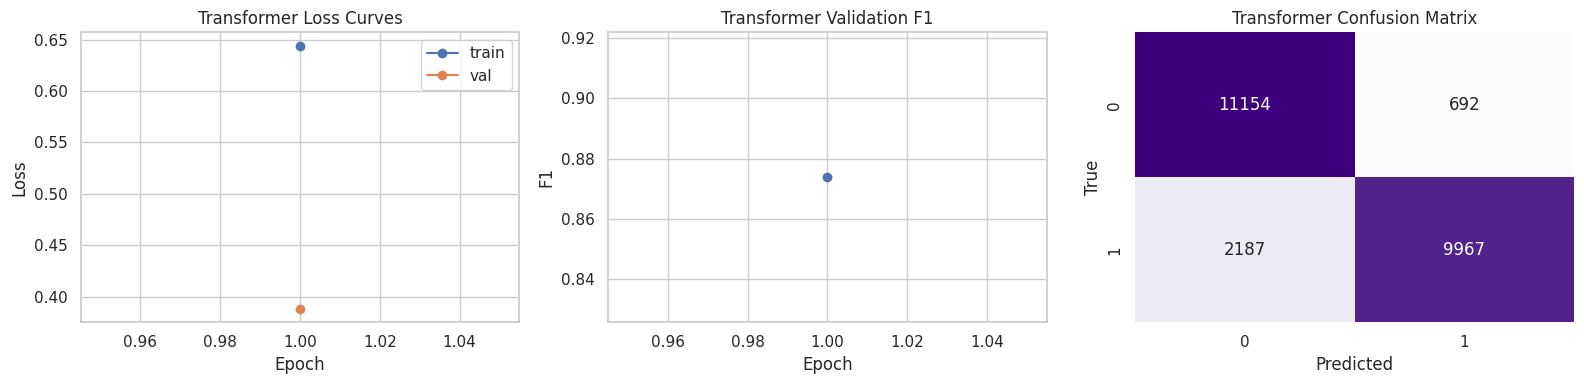

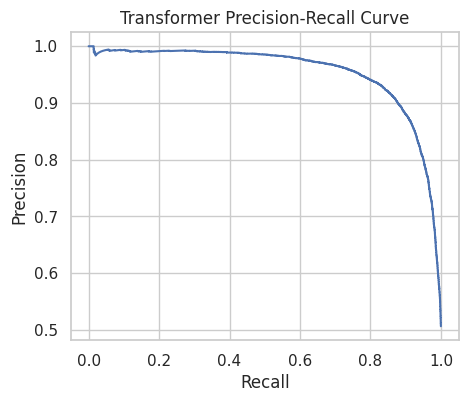

High-confidence correct examples:


,text,true,pred,score_pos
0,An Amazing Album!!!: A great combination of or...,1,1,0.867202
1,True Inspiration!!!: I LOVE being able to LIST...,1,1,0.864663


In [53]:
tr_plot_result = tr_scaled_result if tr_scaled_result is not None else tr_subset_result
tr_hist = tr_plot_result["history_df"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(tr_hist["epoch"], tr_hist["train_loss"], marker="o", label="train")
axes[0].plot(tr_hist["epoch"], tr_hist["val_loss"], marker="o", label="val")
axes[0].set_title("Transformer Loss Curves")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(tr_hist["epoch"], tr_hist["val_f1"], marker="o")
axes[1].set_title("Transformer Validation F1")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("F1")

cm = confusion_matrix(tr_plot_result["y_true"], tr_plot_result["y_pred"])
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples", cbar=False, ax=axes[2])
axes[2].set_title("Transformer Confusion Matrix")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("True")

plt.tight_layout()
plt.show()

prec, rec, _ = precision_recall_curve(tr_plot_result["y_true"], tr_plot_result["y_score"])
plt.figure(figsize=(5, 4))
plt.plot(rec, prec)
plt.title("Transformer Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(True)
plt.show()

print("High-confidence correct examples:")
pd.DataFrame(tr_plot_result["qual_examples"]["correct"])

In [54]:
print("High-confidence incorrect examples:")
pd.DataFrame(tr_plot_result["qual_examples"]["incorrect"])

High-confidence incorrect examples:


,text,true,pred,score_pos
0,"Favorite movie ever!: This is a great movie, r...",0,1,0.855896
1,GOOD IQ TEST: If you liked this movie your IQ ...,0,1,0.855722


In [55]:
def metrics_row(model_name, metrics, runtime_sec=None, inference_note=""):
    return {
        "model": model_name,
        "accuracy": metrics.get("accuracy"),
        "precision": metrics.get("precision"),
        "recall": metrics.get("recall"),
        "f1": metrics.get("f1"),
        "roc_auc": metrics.get("roc_auc"),
        "pr_auc": metrics.get("pr_auc"),
        "train_runtime_sec": runtime_sec,
        "inference_note": inference_note,
    }

rows = []

# Bring in Phase 3 baseline(s) when available
if "baseline_results_df" in globals() and isinstance(baseline_results_df, pd.DataFrame):
    for _, r in baseline_results_df.iterrows():
        rows.append(
            {
                "model": str(r["model"]),
                "accuracy": float(r["accuracy"]),
                "precision": float(r["precision"]),
                "recall": float(r["recall"]),
                "f1": float(r["f1"]),
                "roc_auc": float(r["roc_auc"]),
                "pr_auc": float(r["pr_auc"]),
                "train_runtime_sec": np.nan,
                "inference_note": "fast",
            }
        )

nn_best = nn_scaled_result if nn_scaled_result is not None else nn_subset_result
tr_best = tr_scaled_result if tr_scaled_result is not None else tr_subset_result

rows.append(metrics_row("Phase5 NN", nn_best["metrics"], nn_best["runtime_sec"], "medium"))
rows.append(metrics_row("Phase5 Transformer", tr_best["metrics"], tr_best["runtime_sec"], "heavy"))

model_results_df = pd.DataFrame(rows)
model_results_df = model_results_df.sort_values(
    by=[PRIMARY_METRIC, TIE_BREAK_METRIC], ascending=False
).reset_index(drop=True)
model_results_df["leader"] = False
if len(model_results_df) > 0:
    model_results_df.loc[0, "leader"] = True

metric_cols = ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc", "train_runtime_sec"]
model_results_df[metric_cols] = model_results_df[metric_cols].apply(pd.to_numeric, errors="coerce").round(4)

model_results_df

,model,accuracy,precision,recall,f1,roc_auc,pr_auc,train_runtime_sec,inference_note,leader
0,TF-IDF + SGDClassifier(hinge),0.9052,0.9001,0.9139,0.9070,0.9659,0.9646,NaN,fast,True
1,TF-IDF + LogisticRegression,0.9052,0.9005,0.9134,0.9069,0.9662,0.9649,NaN,fast,False
2,Phase5 NN,0.8866,0.8882,0.8878,0.8880,0.9534,0.9543,40.3555,medium,False
3,Phase5 Transformer,0.8800,0.9351,0.8201,0.8738,0.9526,0.9552,1841.0928,heavy,False


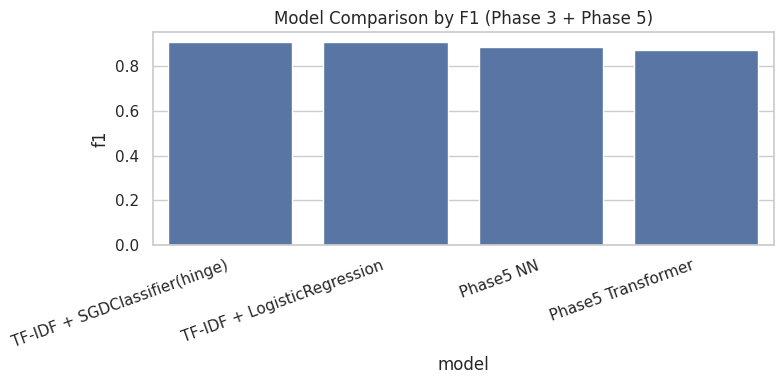

In [56]:
plt.figure(figsize=(8, 4))
plot_df = model_results_df.copy()
plot_df = plot_df.sort_values("f1", ascending=False)
sns.barplot(data=plot_df, x="model", y="f1")
plt.title("Model Comparison by F1 (Phase 3 + Phase 5)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

### Phase 5 Training-Dynamics Interpretation

Fill these after running NN and Transformer cells:

- **Overfitting/underfitting:** compare train vs validation loss gap over epochs for both models.
- **Optimization stability:** identify whether validation F1 is stable or oscillatory.
- **Hyperparameter sensitivity:** summarize effects of sequence length, batch size, and learning rate during subset tuning.
- **Complexity justification:** state whether Transformer gains justify runtime/inference cost over NN and Phase 3 baselines.

Quick interpretation template:

1. NN shows `<stable/unstable>` convergence with `<small/large>` train-val gap.
2. Transformer shows `<stable/unstable>` convergence and improves `<metric>` by `<delta>`.
3. Preferred model under deployment constraints is `<model>` because `<reason>`.

### Phase 6 Handoff: Leakage + Recommendation Criteria

Use this checklist when writing Phase 6:

1. **Tokenizer/vectorizer leakage control**
   - Fit NN vocabulary and Transformer tokenizer usage on train split only.
   - Do not use `test.ft.txt` for any tuning or threshold selection.

2. **Generalization caveats**
   - Report that subset-tuned hyperparameters may still shift under full-data runs.
   - Note domain-shift risk (product categories, review style, time).

3. **Recommendation criteria**
   - Rank by F1 (primary) then ROC-AUC (tie-break).
   - Include runtime and inference cost in decision.
   - Prefer simpler model when performance gains are marginal.

4. **Reproducibility**
   - Keep fixed seeds and record package/runtime context.
   - Document any run that was aborted or downscaled for compute reasons.

## Phase 6: Narrative B — Defensible Final Narrative

This section closes the project with an explicit leakage audit and a deployment-oriented recommendation.

Decision policy:
- Primary metric: **F1**
- Tie-break: **ROC-AUC**
- Supporting context: PR-AUC, runtime, inference cost, interpretability

Data policy reminder:
- `test.ft.txt` remains untouched until final locked evaluation/reporting.

### Section 9: Leakage Audit (Explicit)

Use this checklist and mark each item as pass/fail with brief evidence.

1. **Preprocessing leakage**
   - All train-time transforms (TF-IDF, NN vocab, Transformer training pipeline) are fit using train split only.
   - Validation set is never used for fit operations.

2. **Feature leakage**
   - No target-derived features are used in training.
   - No post-label information is injected into features.

3. **Duplicate/similarity leakage**
   - Check duplicate reviews crossing train/validation boundaries.
   - If detected, report de-duplication policy and rerun affected metrics.

4. **Temporal leakage (limitation-aware)**
   - If reliable timestamps are unavailable in current file format, explicitly state this limitation.
   - If timestamps are available later, add temporal split sensitivity analysis.

5. **Evaluation leakage**
   - Hyperparameter choices are made on train/validation only.
   - Final held-out test is used once after model family/params are locked.

In [58]:
def quick_duplicate_rate(text_series: pd.Series):
    n = len(text_series)
    if n == 0:
        return {"rows": 0, "unique": 0, "duplicate_rate": 0.0}
    unique_n = text_series.nunique(dropna=False)
    return {
        "rows": int(n),
        "unique": int(unique_n),
        "duplicate_rate": float(1 - unique_n / n),
    }


dup_check_rows = min(200_000, len(train_subset_df)) if "train_subset_df" in globals() else 0
if dup_check_rows > 0:
    dup_df = train_subset_df.sample(dup_check_rows, random_state=SEED)
    X_tr_dup, X_va_dup, _, _ = train_test_split(
        dup_df["text"],
        dup_df["label"],
        test_size=VAL_SIZE,
        random_state=SEED,
        stratify=dup_df["label"],
    )

    dup_stats = pd.DataFrame([
        {"split": "train_sample", **quick_duplicate_rate(X_tr_dup.reset_index(drop=True))},
        {"split": "val_sample", **quick_duplicate_rate(X_va_dup.reset_index(drop=True))},
    ])

    overlap = len(set(X_tr_dup.tolist()) & set(X_va_dup.tolist()))
    overlap_rate = overlap / max(1, len(X_va_dup))

    display(dup_stats)
    print(f"Exact text overlap train vs val sample: {overlap} ({overlap_rate:.4%} of val sample)")
else:
    print("Duplicate audit skipped: train_subset_df not available.")

,split,rows,unique,duplicate_rate
0,train_sample,96000,96000,0.0
1,val_sample,24000,24000,0.0


Exact text overlap train vs val sample: 0 (0.0000% of val sample)


### Section 10: Defensible Final Recommendation

Use `model_results_df` to finalize and justify the deployment choice.

Recommendation template:

1. **Best model by policy**
   - Based on F1 (primary) and ROC-AUC (tie-break), the current leader is `model_results_df.iloc[0]['model']` after you run the comparison cell.

2. **Tradeoff statement**
   - If gain vs simpler baseline is small, prefer simpler model for speed/maintenance.
   - If gain is material and stable, justify added complexity.

3. **Operational choice**
   - Inference budget: fast/medium/heavy (from `inference_note`).
   - Training cost: use `train_runtime_sec` to report compute burden.

4. **Failure modes and limitations**
   - Domain shift across product categories/time.
   - Label noise and subjective sentiment language.
   - Residual leakage risk if duplicate handling is incomplete.

5. **Reproducibility statement**
   - Record seed, package versions, and any downscaling choices used to complete runs.

In [57]:
if "model_results_df" in globals() and len(model_results_df) > 0:
    final_decision_df = model_results_df.copy()
    final_decision_df["rank"] = np.arange(1, len(final_decision_df) + 1)
    display(final_decision_df)

    leader = final_decision_df.iloc[0]
    print("Recommended model (current):", leader["model"])
    print(
        "Why:",
        f"F1={leader['f1']:.4f}, ROC-AUC={leader['roc_auc']:.4f}, ",
        f"runtime={leader['train_runtime_sec'] if pd.notna(leader['train_runtime_sec']) else 'n/a'},",
        f"inference={leader['inference_note']}"
    )
else:
    print("Run Phase 5 results table cell first so model_results_df is available.")

,model,accuracy,precision,recall,f1,roc_auc,pr_auc,train_runtime_sec,inference_note,leader,rank
0,TF-IDF + SGDClassifier(hinge),0.9052,0.9001,0.9139,0.9070,0.9659,0.9646,NaN,fast,True,1
1,TF-IDF + LogisticRegression,0.9052,0.9005,0.9134,0.9069,0.9662,0.9649,NaN,fast,False,2
2,Phase5 NN,0.8866,0.8882,0.8878,0.8880,0.9534,0.9543,40.3555,medium,False,3
3,Phase5 Transformer,0.8800,0.9351,0.8201,0.8738,0.9526,0.9552,1841.0928,heavy,False,4


Recommended model (current): TF-IDF + SGDClassifier(hinge)
Why: F1=0.9070, ROC-AUC=0.9659,  runtime=n/a, inference=fast
